In [10]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from linearmodels.iv import IV2SLS
from scipy.stats import gaussian_kde

In [11]:
from linearmodels.datasets import meps

data = meps.load()
data = data.dropna()
print(meps.DESCR)


age               Age
age2              Age-squared
black             Black
blhisp            Black or Hispanic
drugexp           Presc-drugs expense
educyr            Years of education
fair              Fair health
female            Female
firmsz            Firm size
fph               fair or poor health
good              Good health
hi_empunion       Insured thro emp/union
hisp              Hiapanic
income            Income
ldrugexp          log(drugexp)
linc              log(income)
lowincome         Low income
marry             Married
midincome         Middle income
msa               Metropolitan stat area
multlc            Multiple locations
poor              Poor health
poverty           Poor
priolist          Priority list cond
private           Private insurance
ssiratio          SSI/Income ratio
totchr            Total chronic cond
vegood            V-good health
vgh               vg or good health



In [25]:
data[["ldrugexp", "hi_empunion", "ssiratio", "totchr", "female", "age", "linc", "blhisp"]]

,ldrugexp,hi_empunion,ssiratio,totchr,female,age,linc,blhisp
0,6.388561,1,0.149877,0,1,74,4.549085,0.0
1,7.486053,1,0.395856,3,0,73,3.577847,0.0
2,5.170484,0,1.000000,1,1,80,2.261763,0.0
3,7.798523,1,0.206639,5,0,70,3.656221,0.0
4,5.799093,0,0.537192,3,0,91,2.166193,0.0
...,...,...,...,...,...,...,...,...
10386,7.645876,0,1.000000,2,0,83,1.599388,1.0
10387,9.149103,1,0.974529,6,1,72,2.606018,0.0
10388,9.011645,0,0.837477,2,1,80,2.439125,0.0
10389,7.134094,0,1.000000,2,1,67,2.140066,1.0


In [26]:
from sklearn.mixture import GaussianMixture
# Assuming `data` is your original DataFrame with the selected columns
data_subset = data[["ldrugexp", "hi_empunion", "ssiratio", "totchr", "female", "age", "linc", "blhisp"]]

# Fit a Gaussian Mixture Model (GMM) to the data
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=0)  # Adjust n_components as needed
gmm.fit(data_subset)

# Generate synthetic samples
n_samples = 1000  # Define the number of synthetic samples you want
synthetic_samples, _ = gmm.sample(n_samples)

# Convert synthetic data to a DataFrame with the same column names as the original data
synthetic_data = pd.DataFrame(synthetic_samples, columns=data_subset.columns)

# Apply rounding and binarization
synthetic_data["hi_empunion"] = synthetic_data["hi_empunion"].round().astype(int)
synthetic_data["totchr"] = synthetic_data["totchr"].round().astype(int)
synthetic_data["female"] = (synthetic_data["female"] > 0.5).astype(int)  # Binary transformation (0 or 1)
synthetic_data["age"] = synthetic_data["age"].round().astype(int)

# Display synthetic data
synthetic_data.head()

,ldrugexp,hi_empunion,ssiratio,totchr,female,age,linc,blhisp
0,5.807621,0,-1.003440,0,1,68,2.866626,0.067958
1,6.491967,0,1.196857,3,1,73,1.179257,0.103504
2,7.142437,1,1.446277,1,1,63,-2.036547,0.478439
3,9.018570,0,0.600952,1,1,78,-0.563089,-0.018421
4,7.141955,1,-0.914257,2,0,67,0.290044,0.021806


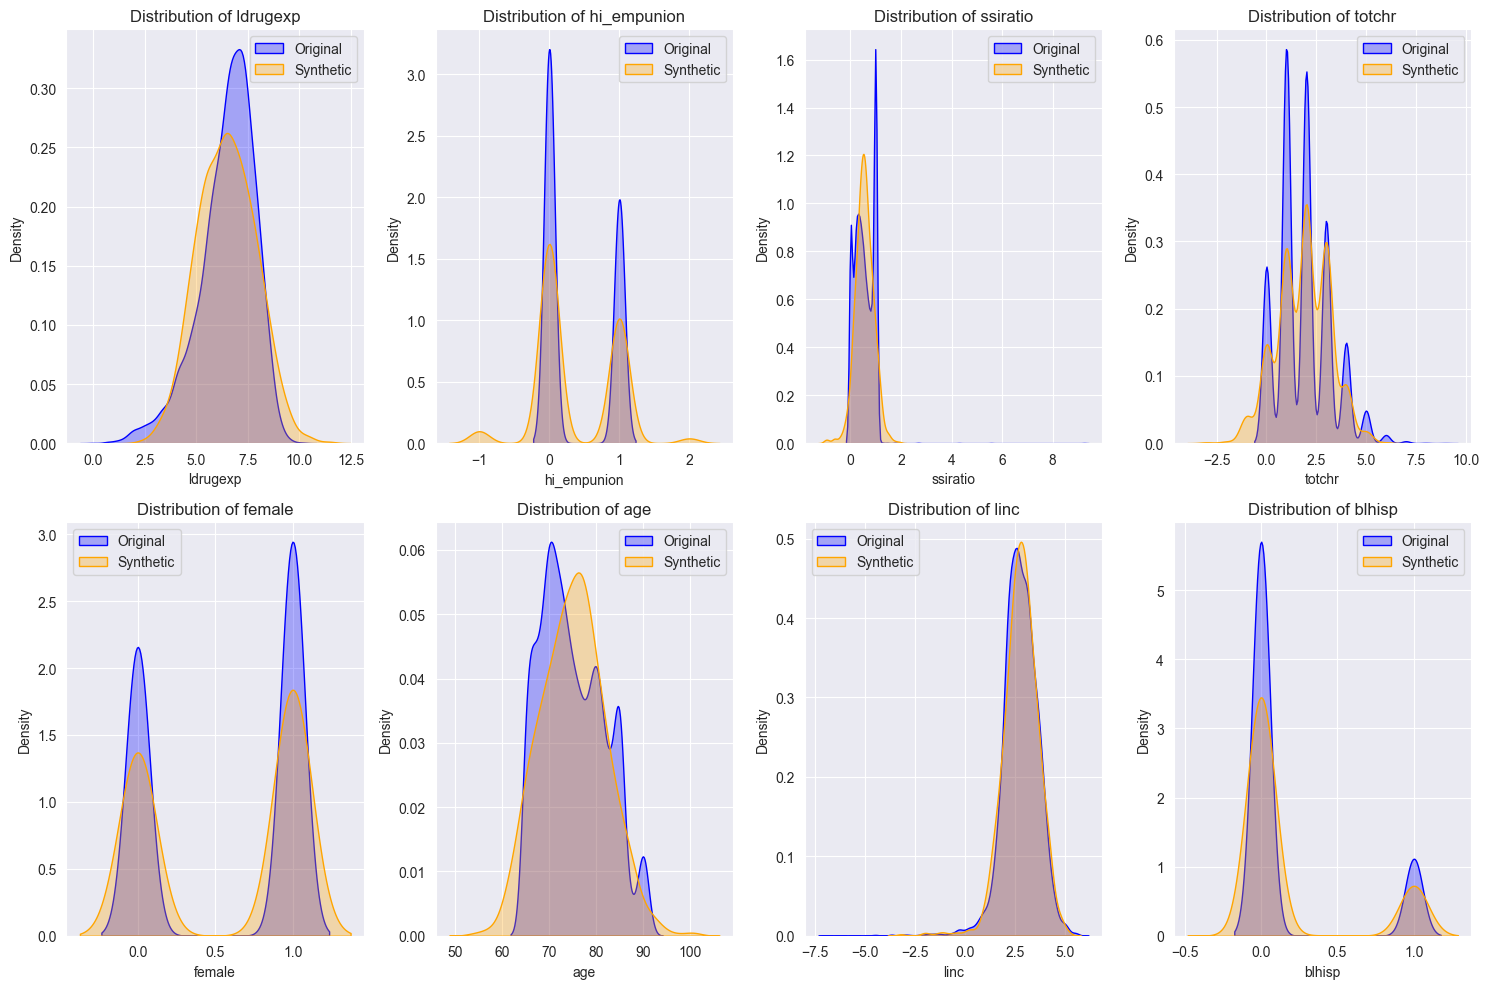

In [28]:
def plot_distributions(original_data, synthetic_data, columns):
    plt.figure(figsize=(15, 10))
    
    for i, col in enumerate(columns, 1):
        plt.subplot(2, (len(columns) + 1) // 2, i)
        
        # Plot original data
        sns.kdeplot(original_data[col], label="Original", color="blue", fill=True, alpha=0.3)
        
        # Plot synthetic data
        sns.kdeplot(synthetic_data[col], label="Synthetic", color="orange", fill=True, alpha=0.3)
        
        plt.title(f"Distribution of {col}")
        plt.legend()
    
    plt.tight_layout()
    plt.show()

# Example usage with your datasets
plot_distributions(data_subset, synthetic_data, columns=data_subset.columns)

In [12]:
controls = ["totchr", "female", "age", "linc", "blhisp"]
print(data[["ldrugexp", "hi_empunion"] + controls].describe(percentiles=[]))

           ldrugexp   hi_empunion        totchr        female           age  \
count  10089.000000  10089.000000  10089.000000  10089.000000  10089.000000   
mean       6.481361      0.382198      1.860938      0.577064     75.051740   
std        1.362052      0.485949      1.292858      0.494050      6.682109   
min        0.000000      0.000000      0.000000      0.000000     65.000000   
50%        6.678342      0.000000      2.000000      1.000000     74.000000   
max       10.180172      1.000000      9.000000      1.000000     91.000000   

               linc        blhisp  
count  10089.000000  10089.000000  
mean       2.743275      0.163544  
std        0.913143      0.369880  
min       -6.907755      0.000000  
50%        2.743160      0.000000  
max        5.744476      1.000000  


In [13]:
instruments = ["ssiratio", "lowincome", "multlc", "firmsz"]
print(data[instruments].describe(percentiles=[]))

           ssiratio     lowincome        multlc        firmsz
count  10089.000000  10089.000000  10089.000000  10089.000000
mean       0.536544      0.187432      0.062048      0.140529
std        0.367818      0.390277      0.241254      2.170389
min        0.000000      0.000000      0.000000      0.000000
50%        0.504522      0.000000      0.000000      0.000000
max        9.250620      1.000000      1.000000     50.000000


In [14]:
data[["hi_empunion"] + instruments].corr()

,hi_empunion,ssiratio,lowincome,multlc,firmsz
hi_empunion,1.000000,-0.212431,-0.116419,0.119849,0.037352
ssiratio,-0.212431,1.000000,0.253946,-0.190433,-0.044578
lowincome,-0.116419,0.253946,1.000000,-0.062465,-0.008232
multlc,0.119849,-0.190433,-0.062465,1.000000,0.187275
firmsz,0.037352,-0.044578,-0.008232,0.187275,1.000000


In [15]:
data["const"] = 1
controls = ["const"] + controls

In [16]:
ivolsmod = IV2SLS(data.ldrugexp, data[["hi_empunion"] + controls], None, None)
res_ols = ivolsmod.fit()
print(res_ols)

                            OLS Estimation Summary                            
Dep. Variable:               ldrugexp   R-squared:                      0.1770
Estimator:                        OLS   Adj. R-squared:                 0.1765
No. Observations:               10089   F-statistic:                    2262.6
Date:                Wed, Oct 30 2024   P-value (F-stat)                0.0000
Time:                        15:39:14   Distribution:                  chi2(6)
Cov. Estimator:                robust                                         
                                                                              
                              Parameter Estimates                              
             Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------
hi_empunion     0.0739     0.0260     2.8441     0.0045      0.0230      0.1248
const           5.8611     0.1570     37.320    

In [17]:
ivmod = IV2SLS(data.ldrugexp, data[controls], data.hi_empunion, data.ssiratio)
res_2sls = ivmod.fit()
print(res_2sls.summary)

                          IV-2SLS Estimation Summary                          
Dep. Variable:               ldrugexp   R-squared:                      0.0640
Estimator:                    IV-2SLS   Adj. R-squared:                 0.0634
No. Observations:               10089   F-statistic:                    2000.9
Date:                Wed, Oct 30 2024   P-value (F-stat)                0.0000
Time:                        15:39:21   Distribution:                  chi2(6)
Cov. Estimator:                robust                                         
                                                                              
                              Parameter Estimates                              
             Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------
const           6.7872     0.2688     25.246     0.0000      6.2602      7.3141
totchr          0.4503     0.0102     44.157    

In [19]:
ivmod = IV2SLS(
    data.ldrugexp, data[controls], data.hi_empunion, data[["ssiratio", "multlc"]]
)
res_2sls_robust = ivmod.fit()
print(res_2sls_robust.summary)

                          IV-2SLS Estimation Summary                          
Dep. Variable:               ldrugexp   R-squared:                      0.0414
Estimator:                    IV-2SLS   Adj. R-squared:                 0.0409
No. Observations:               10089   F-statistic:                    1955.4
Date:                Wed, Oct 30 2024   P-value (F-stat)                0.0000
Time:                        15:39:37   Distribution:                  chi2(6)
Cov. Estimator:                robust                                         
                                                                              
                              Parameter Estimates                              
             Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------
const           6.8752     0.2579     26.660     0.0000      6.3697      7.3806
totchr          0.4512     0.0103     43.769    

In [178]:
# Parameters
n_population = 10000  # Full population size
n_sample = 2000  # Observed sample size
instrument_strength = 0.25  # Strength of the instrument's correlation with treatment uptake

def clinical_trial_model(p_treatment: float = 2., health_impact_treatment: float = None, health_impact_ability: float = None):
    # Generate true population data
    baseline_health = np.random.normal(0, 1, n_population)  # Unobserved baseline health factor
    if health_impact_treatment is None:
        health_impact_treatment = np.random.uniform(0.5, 5)  # 3
    if health_impact_ability is None:
        health_impact_ability = np.random.uniform(0.1, 1)  # 0.8
    
    # Instrument: distance to nearest treatment facility (affects treatment uptake but not health directly)
    distance_to_facility = np.clip(np.random.normal(10, 5, n_population), 1, 100)
    
    # Treatment uptake is influenced by baseline health and distance to the facility (the instrument)
    treatment_uptake = 1 + health_impact_ability * baseline_health - instrument_strength * distance_to_facility + np.random.normal(0, 1, n_population)
    treatment_uptake = (treatment_uptake > 0).astype(int)  # Binary treatment uptake (1 if treatment received, 0 otherwise)
    
    # Health outcome depends on treatment uptake and baseline health (baseline health is unobserved)
    true_health_outcomes = 50 + p_treatment * treatment_uptake + health_impact_treatment * baseline_health + np.random.normal(0, 2, n_population)
    true_health_outcomes[true_health_outcomes < 0] = 0  # Health outcomes cannot be negative
    
    # Create a participation probability based on baseline health
    participation_prob = np.clip(0.2 - 0.2 * baseline_health, 0, 1)
    participation = np.random.binomial(1, participation_prob, n_population)

    # Create observed sample (sample where individuals' health outcomes are observed)
    observed_indices = np.where(participation == 1)[0]
    _n_sample = min(n_sample, len(observed_indices))
    observed_sample_indices = np.random.choice(observed_indices, _n_sample, replace=False)
    
    # Create the observed sample data
    observed_data = pd.DataFrame({
        'treatment_uptake': treatment_uptake[observed_sample_indices],
        'distance_to_facility': distance_to_facility[observed_sample_indices],  # Instrument
        'true_health_outcomes': true_health_outcomes[observed_sample_indices],  # Actual health outcomes
    })
    
    # Full population data (for reference)
    population_data = pd.DataFrame({
        'treatment_uptake': treatment_uptake,
        'distance_to_facility': distance_to_facility,  # Instrument
        'true_health_outcomes': true_health_outcomes,  # Actual health outcomes for the full population
        'participation': participation  # Whether they are included in the observed sample
    })
    return observed_data, population_data

In [179]:
np.random.seed(42)
true_param = 1.7
obs, pop = clinical_trial_model(true_param, health_impact_treatment=0.8, health_impact_ability=3)
print(obs.shape)

(2000, 3)


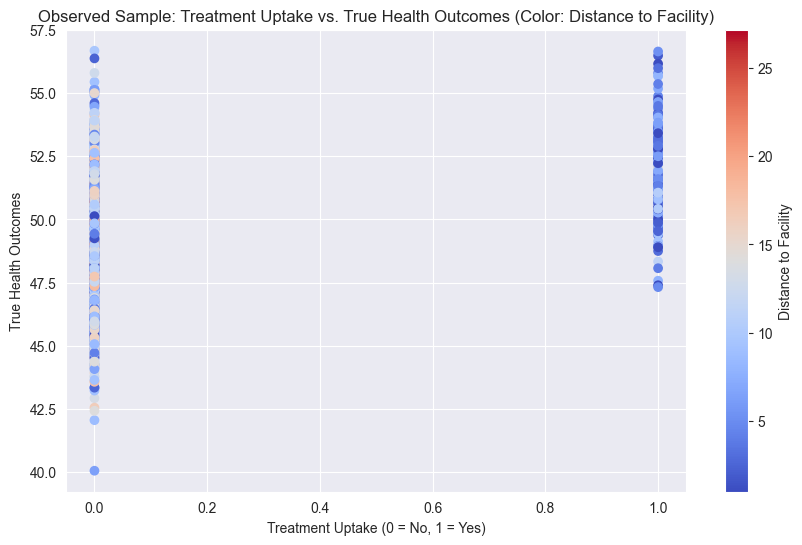

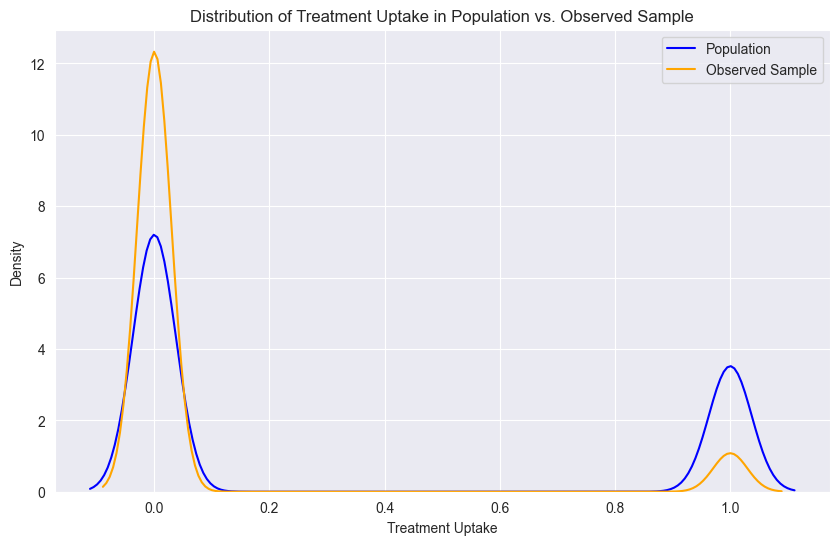

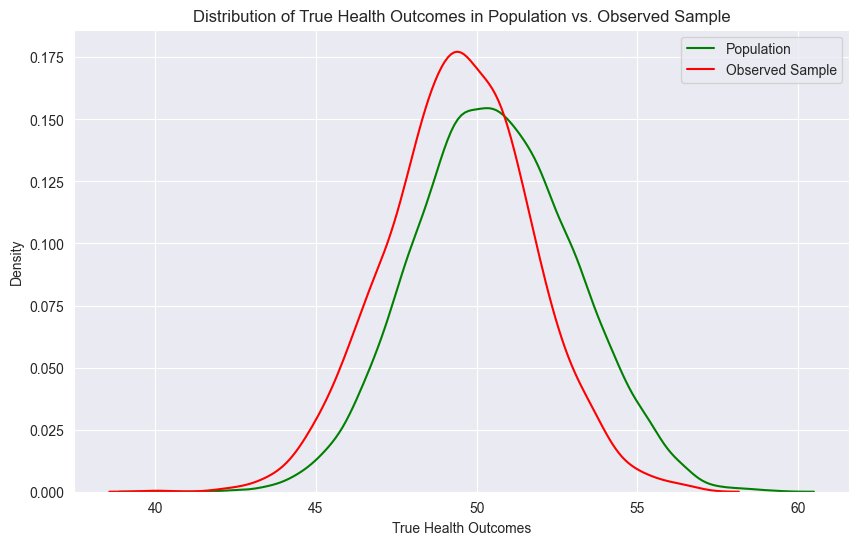

In [180]:
# Visualizing the relationship between treatment uptake and true health outcomes in the observed sample
plt.figure(figsize=(10, 6))
scatter = plt.scatter(x=obs['treatment_uptake'], y=obs['true_health_outcomes'], c=obs['distance_to_facility'], cmap='coolwarm')
plt.title('Observed Sample: Treatment Uptake vs. True Health Outcomes (Color: Distance to Facility)')
plt.xlabel('Treatment Uptake (0 = No, 1 = Yes)')
plt.ylabel('True Health Outcomes')
plt.colorbar(scatter, label='Distance to Facility')
plt.show()

# Visualizing the distribution of treatment uptake in both the population and observed sample
plt.figure(figsize=(10, 6))
sns.kdeplot(pop['treatment_uptake'], label='Population', color='blue', bw_adjust=0.5)
sns.kdeplot(obs['treatment_uptake'], label='Observed Sample', color='orange', bw_adjust=0.5)
plt.title('Distribution of Treatment Uptake in Population vs. Observed Sample')
plt.xlabel('Treatment Uptake')
plt.ylabel('Density')
plt.legend()
plt.show()

# Visualizing the distribution of health outcomes in both the population and observed sample
plt.figure(figsize=(10, 6))
sns.kdeplot(pop['true_health_outcomes'], label='Population', color='green')
sns.kdeplot(obs['true_health_outcomes'], label='Observed Sample', color='red')
plt.title('Distribution of True Health Outcomes in Population vs. Observed Sample')
plt.xlabel('True Health Outcomes')
plt.ylabel('Density')
plt.legend()
plt.show()

In [181]:
# Set up the IV model
obs['constant'] = 1.

ols_model = IV2SLS(
    dependent=obs['true_health_outcomes'], 
    exog=obs[['constant', 'treatment_uptake']], 
    endog=None, 
    instruments=None
)

# Fit the model
ols_results = ols_model.fit()

# Show OLS results
print(ols_results.summary)
ols_result = {
    'params': ols_results.params['treatment_uptake'],
    'CI': ols_results.conf_int().loc['treatment_uptake'].values
}

                             OLS Estimation Summary                             
Dep. Variable:     true_health_outcomes   R-squared:                      0.1052
Estimator:                          OLS   Adj. R-squared:                 0.1047
No. Observations:                  2000   F-statistic:                    303.33
Date:                  Wed, Oct 30 2024   P-value (F-stat)                0.0000
Time:                          15:36:27   Distribution:                  chi2(1)
Cov. Estimator:                  robust                                         
                                                                                
                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
constant             49.238     0.0504     977.29     0.0000      49.140      49.337
treatment_up

In [182]:
# Set up the IV model
res_first = IV2SLS(
    dependent=obs['treatment_uptake'], 
    exog=obs[['constant', 'distance_to_facility']], 
    endog=None,
    instruments=None
)

# Fit the model
first_results = res_first.fit()

# Show results
print(first_results.summary)  # F-test should be at least 10

                            OLS Estimation Summary                            
Dep. Variable:       treatment_uptake   R-squared:                      0.0691
Estimator:                        OLS   Adj. R-squared:                 0.0687
No. Observations:                2000   F-statistic:                    120.24
Date:                Wed, Oct 30 2024   P-value (F-stat)                0.0000
Time:                        15:36:27   Distribution:                  chi2(1)
Cov. Estimator:                robust                                         
                                                                              
                                  Parameter Estimates                                   
                      Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------------
constant                 0.2340     0.0187     12.509     0.0000      0.1974      0.2707
distance_to_

In [183]:
# Set up the IV model
iv_model = IV2SLS(
    dependent=obs['true_health_outcomes'], 
    exog=obs[['constant']], 
    endog=obs[['treatment_uptake']],
    instruments=obs['distance_to_facility']
)

# Fit the model
iv_results = iv_model.fit() #cov_type="unadjusted")

# Show results, which include correct CIs
print(iv_results.summary)
iv_result = {
    'params': iv_results.params['treatment_uptake'],
    'CI': iv_results.conf_int().loc['treatment_uptake'].values
}

                           IV-2SLS Estimation Summary                           
Dep. Variable:     true_health_outcomes   R-squared:                      0.1013
Estimator:                      IV-2SLS   Adj. R-squared:                 0.1009
No. Observations:                  2000   F-statistic:                    11.183
Date:                  Wed, Oct 30 2024   P-value (F-stat)                0.0008
Time:                          15:36:28   Distribution:                  chi2(1)
Cov. Estimator:                  robust                                         
                                                                                
                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
constant             49.280     0.0710     694.03     0.0000      49.141      49.419
treatment_up

In [184]:
ols_result, iv_result

({'params': 2.6939710089556548, 'CI': array([2.39080132, 2.9971407 ])},
 {'params': 2.176058840067202, 'CI': array([0.90069495, 3.45142273])})

# Use BayesFlow

In [185]:
import bayesflow as bf
from bayesflow.networks import InvertibleNetwork, DeepSet
from bayesflow.amortizers import AmortizedPosterior
from bayesflow.trainers import Trainer

In [186]:
posterior_samples_dict = {
    'instrument_observed': None,
    'no_instrument_observed': None,
}
param_names = ['treatment_uptake']

In [187]:
instrument_observed = True

In [188]:
def generative_model(n_samples: int = None, param_batch: np.ndarray = None):
    if param_batch is None:
        if n_samples is None:
            raise ValueError("Either n_samples or param_batch must be provided.")
        param_batch = np.random.uniform(0, 5, size=(n_samples, 1))
    
    # Initialize data array
    data = np.zeros((len(param_batch), n_sample, 3 if instrument_observed else 2))
    for i, param in enumerate(param_batch):
        # Generate data for the clinical model with the given parameter
        data_i, _ = clinical_trial_model(param[0])  # Only one parameter in the batch
        
        # Include instrument in data if observed, otherwise exclude it
        if instrument_observed:
            data_i = data_i[['true_health_outcomes', 'treatment_uptake', 'distance_to_facility']].values
        else:
            data_i = data_i[['true_health_outcomes', 'treatment_uptake']].values
            
        # Ensure data has the correct sample size, pad if necessary
        if data_i.shape[0] < n_sample:
            data_i = np.pad(data_i, ((0, n_sample - data_i.shape[0]), (0, 0)), mode='constant', constant_values=-0.1)
        
        data[i] = data_i  # Assign to batch data
    
    return {'sim_data': data, 'prior_draws': param_batch}


In [189]:
summary_net = DeepSet(summary_dim=2)

inference_net = InvertibleNetwork(
    num_params=len(param_names),
    num_coupling_layers=3,
    permutation="learnable"
)
amortizer = AmortizedPosterior(
    inference_net=inference_net,
    summary_net=summary_net,
)

In [190]:
np.random.seed(42)
_sim_data = generative_model(1000)
prior_mean = _sim_data['prior_draws'].mean(axis=0)
prior_std = _sim_data['prior_draws'].std(axis=0)
x_mean = np.log1p(_sim_data['sim_data']).mean(axis=0)
x_std = np.log1p(_sim_data['sim_data']).std(axis=0)

In [191]:
def configurator(forward_dict: dict) -> dict:
    # Extract data
    x = forward_dict["sim_data"]
    x = np.log1p(x)
    x = (x - x_mean) / x_std
    out_dict = {
        'summary_conditions': x.astype(np.float32)
    }

    # Extract params
    if 'parameters' in forward_dict.keys():
        forward_dict["prior_draws"] = forward_dict["parameters"]
    if 'prior_draws' in forward_dict.keys():
        params = forward_dict["prior_draws"]
        # normalize
        params = (params - prior_mean) / prior_std
        out_dict['parameters'] = params.astype(np.float32)
    return out_dict

In [192]:
trainer = Trainer(
    amortizer=amortizer,
    configurator=configurator,
    generative_model=generative_model,
    checkpoint_path='amortizer_education_IV' if instrument_observed else 'amortizer_education',
)

INFO:root:Loaded loss history from amortizer_education_IV/history_30.pkl.
INFO:root:Networks loaded from amortizer_education_IV/ckpt-30
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [193]:
%%time
np.random.seed(42)
offline_data = generative_model(10000)
valid_data = generative_model(256)
prior_draws = valid_data['prior_draws']

CPU times: user 13.9 s, sys: 331 ms, total: 14.2 s
Wall time: 14.2 s


In [194]:
if not os.path.exists(trainer.checkpoint_path):
    history = trainer.train_offline(
        simulations_dict=offline_data,
        epochs=30,
        batch_size=128,
        early_stopping=True,
        validation_sims=valid_data
    )
else:
    trainer.load_pretrained_network()
    history = trainer.loss_history.get_plottable()

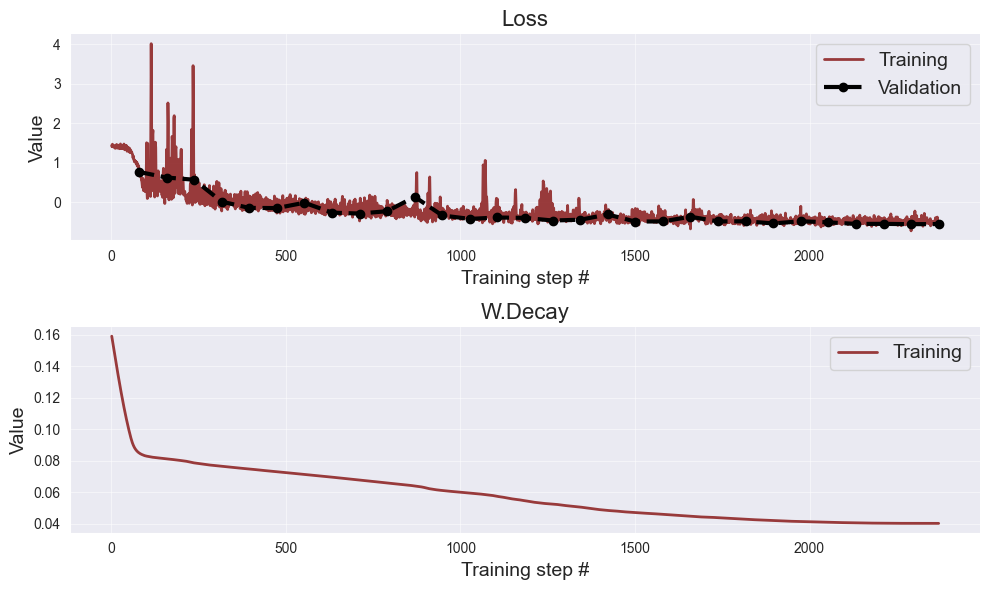

In [195]:
bf.diagnostics.plot_losses(history['train_losses'], history['val_losses'], fig_size=(10, 6));

In [196]:
posterior_samples = trainer.amortizer.sample(trainer.configurator(valid_data), n_samples=100)
posterior_samples = posterior_samples * prior_std + prior_mean

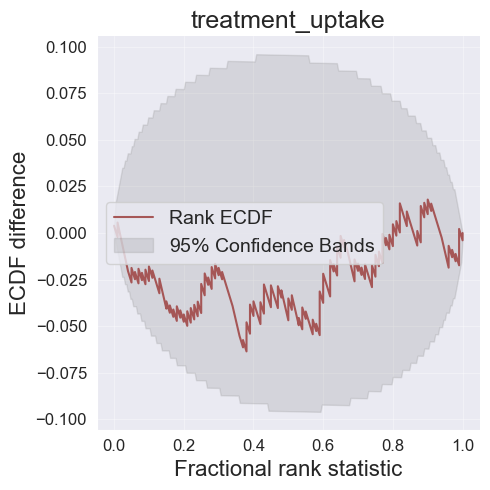

In [197]:
bf.diagnostics.plot_sbc_ecdf(posterior_samples, prior_draws, difference=True, param_names=param_names);

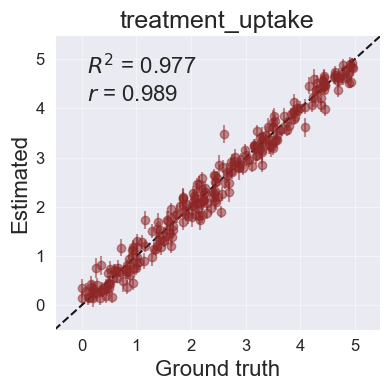

In [198]:
bf.diagnostics.plot_recovery(posterior_samples, prior_draws, param_names=param_names);

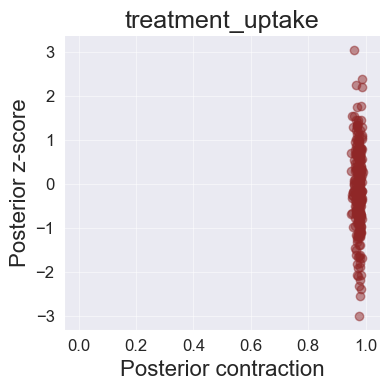

In [199]:
bf.diagnostics.plot_z_score_contraction(posterior_samples, prior_draws, param_names=param_names);

## Test Data

In [200]:
if instrument_observed:
    test_data = {'sim_data': obs[['true_health_outcomes', 'treatment_uptake', 'distance_to_facility']].values[np.newaxis]}
else:
    test_data = {'sim_data': obs[['true_health_outcomes', 'treatment_uptake']].values[np.newaxis]}
    
# Generate posterior samples using the trainer's amortizer and configurator for the test data
posterior_samples = trainer.amortizer.sample(trainer.configurator(test_data), n_samples=1000)

# Adjust posterior samples by scaling with prior standard deviation and mean
posterior_samples = posterior_samples * prior_std + prior_mean

# Store posterior samples based on whether the instrument is observed
if instrument_observed:
    posterior_samples_dict['instrument_observed'] = posterior_samples.copy()
else:
    posterior_samples_dict['no_instrument_observed'] = posterior_samples.copy()

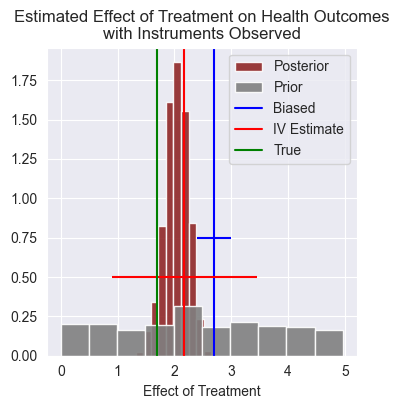

In [201]:
fig = plt.figure(figsize=(4, 4))
plt.hist(posterior_samples, density=True, alpha=0.9, color="#8f2727", label='Posterior')
plt.hist(prior_draws, density=True, alpha=0.9, color="gray", label='Prior')

# Add reference lines for different estimates
plt.axvline(ols_result['params'], color='b', label='Biased')
plt.errorbar(ols_result['params'], 0.75, xerr=np.abs(ols_result['CI'][:, np.newaxis]-ols_result['params']), color='b')

plt.axvline(iv_result['params'], color='r', label='IV Estimate')
plt.errorbar(iv_result['params'], 0.5, xerr=np.abs(iv_result['CI'][:, np.newaxis]-iv_result['params']), color='r')

plt.axvline(true_param, color='g', label='True')

plt.legend()
plt.xlabel('Effect of Treatment')
plt.title(f'Estimated Effect of Treatment on Health Outcomes\n{"with Instruments Observed" if instrument_observed else ""}')
plt.show()

In [202]:
if posterior_samples_dict['instrument_observed'] is not None and posterior_samples_dict['no_instrument_observed'] is not None:
    fig = plt.figure(figsize=(4, 4))
    x = np.linspace(0, 5, 1000)
    
    # KDE plot for posterior samples with observed instrument
    kde = gaussian_kde(posterior_samples_dict['instrument_observed'].flatten())
    plt.plot(x, kde(x), color='#8f2727', label='Posterior with Observed Instrument')
    
    # KDE plot for posterior samples without observed instrument
    kde_no = gaussian_kde(posterior_samples_dict['no_instrument_observed'].flatten())
    plt.plot(x, kde_no(x), color='#8f5727', label='Posterior')
    
    # Add reference lines for different estimates
    plt.axvline(ols_result['params'], color='b', label='Biased')
    plt.axvline(iv_result['params'], color='r', label='IV Estimate')
    plt.axvline(true_param, color='g', label='True')
    
    plt.legend(loc='lower left')
    plt.xlabel('Effect of Treatment')
    plt.title('Posterior Distributions of Treatment Effect on Health Outcomes')
    plt.show()